##  SGS

In [22]:
# import from package 'geone'
from geone import img
import geone.imgplot as imgplt
import geone.customcolors as ccol
import geone.deesseinterface as dsi

import pandas as pd
import numpy as np

import pickle
from geone import grf
import krigeage as kg

import matplotlib.pyplot as plt

### Import the data

In [4]:
path_ti = 'datas/TI/pickle/ti_alt1_alti3d.pickle'
with open(path_ti,'rb') as file:
    ti = pickle.load(file)

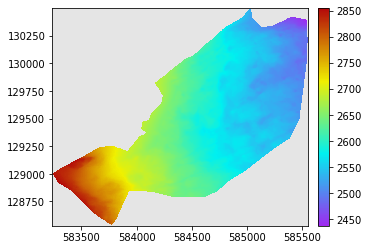

In [6]:
imgplt.drawImage2D(ti)

### Prepare the data

In [18]:
ti_pts = img.imageToPointSet(ti)
ti_pts = img.pointSetToPandas(ti_pts)

In [27]:
ti_pts = ti_pts.sample(frac=0.1)

In [28]:
ti_pts = ti_pts.dropna()

In [29]:
ti_pts.head()

,X,Y,Z,alt
1026696,585349.0,130307.0,0.5,2487.708
433774,584535.0,129281.0,0.5,2597.137
253178,583703.0,128969.0,0.5,2747.167
386600,584897.0,129199.0,0.5,2566.937
862720,585417.0,130023.0,0.5,2500.494


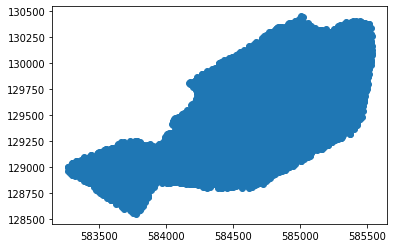

In [30]:
plt.scatter(ti_pts['X'],ti_pts['Y'])

### Remove the trend of the data in order to calculate the variogram

In [31]:
from sklearn.linear_model import LinearRegression as lr 

In [294]:
X = [[x,y] for x,y in zip(ti_pts['X'],ti_pts['Y'])]
X = np.array(X)
Y = np.array(ti_pts['alt'])
X,Y

(array([[585349., 130307.],
        [584535., 129281.],
        [583703., 128969.],
        ...,
        [584797., 129539.],
        [585029., 129115.],
        [584473., 128803.]]),
 array([2487.708, 2597.137, 2747.167, ..., 2558.41 , 2565.769, 2640.157]))

In [34]:
regLinear = lr().fit(X,Y)
regLinear.score(X,Y), regLinear.coef_

(0.9542311415554888, array([-0.14396598, -0.015295  ]))

In [35]:
trend_alt = regLinear.predict(X)
alt       = ti_pts['alt']-trend_alt

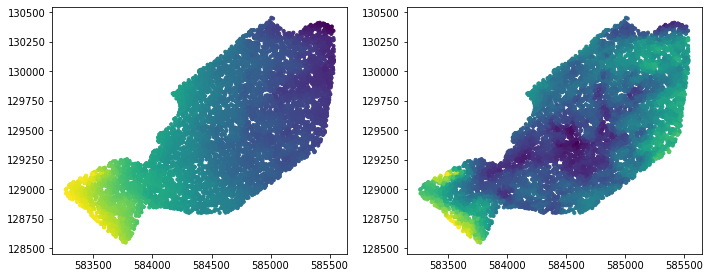

In [36]:
fig  = plt.subplots(1,2,figsize=(10,10))
plt.subplot(1,2,1)
plt.scatter(X[:,0],X[:,1],s=10,c=ti_pts['alt'])
plt.axis('scaled')
plt.subplot(1,2,2)
plt.scatter(X[:,0],X[:,1],s=10,c=alt)
plt.axis('scaled')
plt.tight_layout()

### Semi variogramme

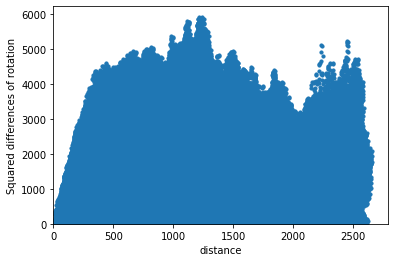

In [37]:
#Variogramme cloud
hc,gc = kg.cloud(X[:,0],X[:,1],alt)
plt.scatter(hc, gc, s=10)
plt.xlabel('distance')
plt.ylabel('Squared differences')
plt.xlim(xmin=0)
plt.ylim(ymin=0)
plt.show()

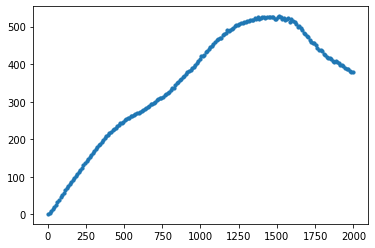

In [42]:
#Experimental variogram
he, ge = kg.experimental(hc,gc,10,200)
plt.scatter(he,ge,s=10)
plt.show()

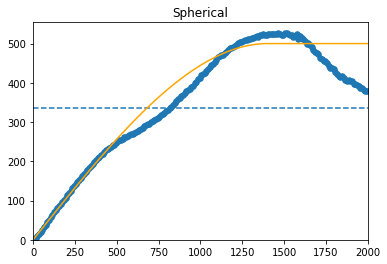

In [49]:
#Fit the experimental model
lag, nlag      = 10, 200
sillE, rangeE  = 500 , 1400
x   = np.linspace(0, nlag * lag, 1000)
y_1 = kg.spherical(x, sillE, rangeE)
y_2 = kg.nugget(x, 0)
y   = y_1 + y_2
plt.scatter(he, ge, s=30)
variance = np.var(alt)
plt.axhline(variance, linestyle='--')
plt.xlim(xmin=0, xmax=lag * nlag)
plt.ylim(ymin=0)
plt.title('Spherical')
plt.plot(x, y,color='orange')
plt.show()

### Gaussian random field

#### Define a covariance model

In [47]:
import geone.covModel as gcm
import geone.customcolors as ccol

In [177]:
cov_model = gcm.CovModel2D(elem=[
    ('spherical', {'w':500., 'r':[1400]}), # elementary contribution
                       ], alpha=0, name='model-2D test')

In [178]:
cov_fun = cov_model.func()
vario_fun = cov_model.vario_func()

In [179]:
w = cov_model.sill() # scalar
r = cov_model.r12()  # vector (1d-array) of length 2

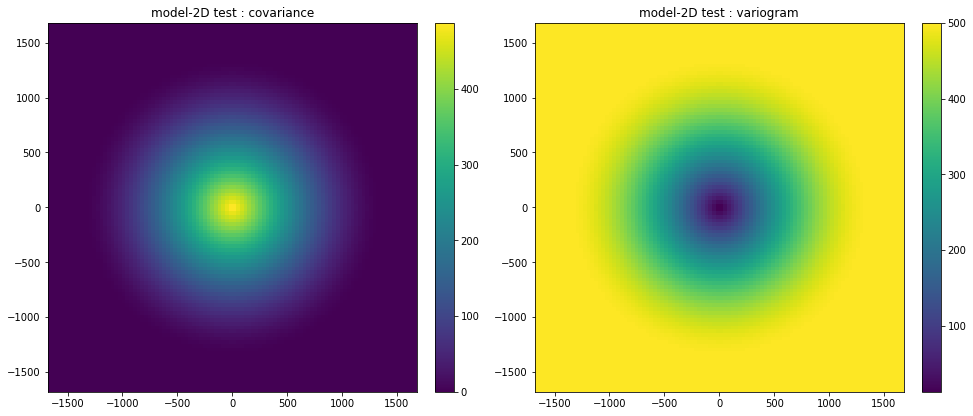

In [180]:
rmax = max(r)
hx = np.linspace(-1.2*rmax, 1.2*rmax, 100)
hy = np.linspace(-1.2*rmax, 1.2*rmax, 100)

hhx, hhy = np.meshgrid(hx, hy)

hh = np.hstack((hhx.reshape(-1,1), hhy.reshape(-1,1))) # 2D-lags: (n,2)-array
ch = cov_fun(hh).reshape(len(hy), len(hx))
vh = vario_fun(hh).reshape(len(hy), len(hx))

xmin, xmax = min(hx), max(hx)
ymin, ymax = min(hy), max(hy)

plt.subplots(1,2,figsize=(16,8)) # plot with 2 sub-plots

# first sub-plot: covariance model
plt.subplot(1,2,1)
im_plot = plt.imshow(ch, cmap='viridis', origin='lower', 
                     extent=[xmin,xmax,ymin,ymax],
                     interpolation='none')
plt.title('{} : covariance'.format(cov_model.name))
ccol.add_colorbar(im_plot)

# first sub-plot: variogram model
plt.subplot(1,2,2)
im_plot = plt.imshow(vh, cmap='viridis', origin='lower', 
                     extent=[xmin,xmax,ymin,ymax],
                     interpolation='none')
plt.title('{} : variogram'.format(cov_model.name))
ccol.add_colorbar(im_plot)



#### Simulation of GRF's 2D

In [65]:
#test non conditionné
nx, ny = 220, 230  # number of cells
dx, dy = 1.0, 1.0  # cell unit
ox, oy = 0.0, 0.0  # origin

dimension = [nx, ny]
spacing = [dx, dy]
origin = [ox, oy]

In [66]:
extensionMin = [grf.extension_min(r, n, s) for r, n, s in zip(cov_model.rxy(), dimension, spacing)]

In [67]:
nreal = 10
np.random.seed(123)
sim2Da = grf.grf2D(cov_fun, dimension, spacing, origin, 
                   extensionMin=extensionMin, nreal=nreal)

GRF2D: Preliminary computation...
GRF2D: Computing circulant embedding...
GRF2D: Embedding dimension: 4096 x 4096
GRF2D: Computing FFT of circulant matrix...
GRF2D: Unconditional simulation    1-   2 of   10...
GRF2D: Unconditional simulation    3-   4 of   10...
GRF2D: Unconditional simulation    5-   6 of   10...
GRF2D: Unconditional simulation    7-   8 of   10...
GRF2D: Unconditional simulation    9-  10 of   10...


In [68]:
sim2Da_mean = np.mean(sim2Da.reshape(nreal, -1), axis=0).reshape(ny, nx)
sim2Da_std = np.std(sim2Da.reshape(nreal, -1), axis=0).reshape(ny, nx)

Text(0.5, 1.0, 'standard deviation over 10 real')

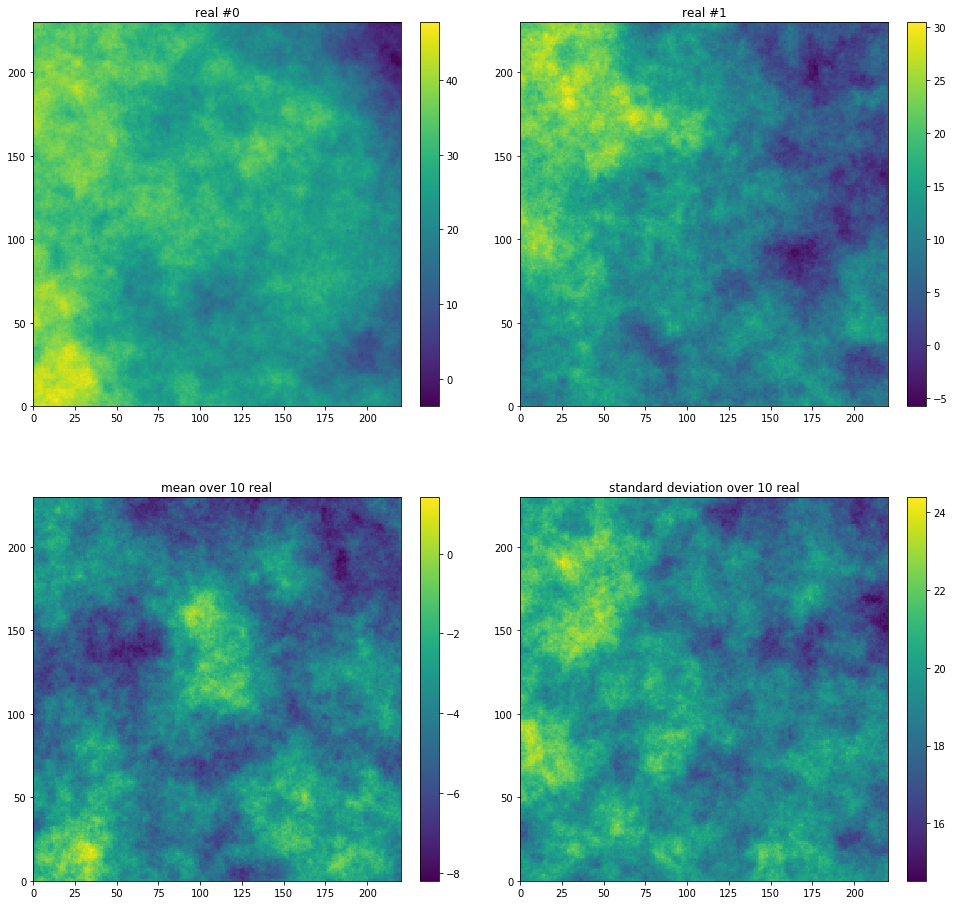

In [69]:
# xg, yg: coordinates of the centers of grid cells
xg = ox + 0.5*dx + dx*np.arange(nx)
yg = oy + 0.5*dy + dy*np.arange(ny)
xmin, xmax = ox, ox + nx * dx
ymin, ymax = oy, oy + ny * dy

plt.subplots(2, 2,figsize=(16,16)) # plot with 4 sub-plots

# 2 first sub-plots: 2 first realizations
for i in (0, 1):
    plt.subplot(2,2,i+1)
    im_plot = plt.imshow(sim2Da[i], origin='lower', 
                         extent=[xmin,xmax,ymin,ymax],
                         interpolation='none')
    ccol.add_colorbar(im_plot)
    plt.title('real #{}'.format(i))

# 3rd sub-plot: mean
plt.subplot(2,2,3)
im_plot = plt.imshow(sim2Da_mean, origin='lower', 
                     extent=[xmin,xmax,ymin,ymax],
                     interpolation='none')
ccol.add_colorbar(im_plot)
plt.title('mean over {} real'.format(nreal))

# 4th sub-plot: standard deviation
plt.subplot(2,2,4)
im_plot = plt.imshow(sim2Da_std, origin='lower', 
                     extent=[xmin,xmax,ymin,ymax],
                     interpolation='none')
ccol.add_colorbar(im_plot)
plt.title('standard deviation over {} real'.format(nreal))

#### Conditionnal simulation: import the data

In [73]:
exec(open('./functions/04_function.py').read())

In [74]:
path_data = 'generated_data/'
name = 'realisation0.pickle'
trueMNT, position, hd_df, ti = read_data(path_data,name)

In [268]:
def create_hd_grf(hd_df, position):
    hd_df = hd_df.sample(frac=1)
    hd_df = hd_df[hd_df['cell_x']!=position[1]]
    hd_df = hd_df[hd_df['cell_y']!=position[3]]
    
    X = np.array([[float(x),float(y)] for x,y in zip(hd_df['cell_x'],hd_df['cell_y'])])
    Y = np.array(hd_df['alt'])
    
    X,Y = remove_duplicate(X,Y)
    return X,Y

def create_grid(position):
    nx,ny = int(position[1]-position[0]), int(position[3]-position[2])
    sx,sy = 1.0, 1.0
    ox,oy = float(position[0]), float(position[2])
    
    dimension = [nx,ny]
    spacing   = [sx,sy]
    origin    = [ox,oy]
    
    return dimension, spacing, origin

def remove_duplicate(X,Y): 
    X, position = np.unique(X,axis=0,return_index=True)
    Y = Y[position]

    return X,Y

In [269]:
X,Y = create_hd_grf(hd_df,position)
dimension, spacing, origin = create_grid(position)
extensionMin = [grf.extension_min(r, n, s) for r, n, s in zip(cov_model.rxy(), dimension, spacing)]

In [270]:
np.random.seed(123)
sim2Db = grf.grf2D(cov_fun, dimension, spacing, origin, x=X, v=Y, 
                   extensionMin=extensionMin, nreal=int(nreal))
nx, ny = dimension[0],dimension[1]
sim2Db_mean = np.mean(sim2Db.reshape(nreal, -1), axis=0).reshape(ny, nx)
sim2Db_std = np.std(sim2Db.reshape(nreal, -1), axis=0).reshape(ny, nx)

GRF2D: Preliminary computation...
GRF2D: Computing circulant embedding...
GRF2D: Embedding dimension: 4096 x 4096
GRF2D: Computing FFT of circulant matrix...
GRF2D: Treatment of conditioning data...
GRF2D: Computing covariance matrix (rAA) for conditioning locations...
GRF2D: Computing index in the embedding grid for non-conditioning / conditioning locations...
GRF2D: Unconditional simulation    1-   2 of   10...
GRF2D: Unconditional simulation    3-   4 of   10...
GRF2D: Unconditional simulation    5-   6 of   10...
GRF2D: Unconditional simulation    7-   8 of   10...
GRF2D: Unconditional simulation    9-  10 of   10...
GRF2D: Updating conditional simulation    1 of   10...
GRF2D: Updating conditional simulation    2 of   10...
GRF2D: Updating conditional simulation    3 of   10...
GRF2D: Updating conditional simulation    4 of   10...
GRF2D: Updating conditional simulation    5 of   10...
GRF2D: Updating conditional simulation    6 of   10...
GRF2D: Updating conditional simulation   

Text(0.5, 1.0, 'standard deviation over 10 real')

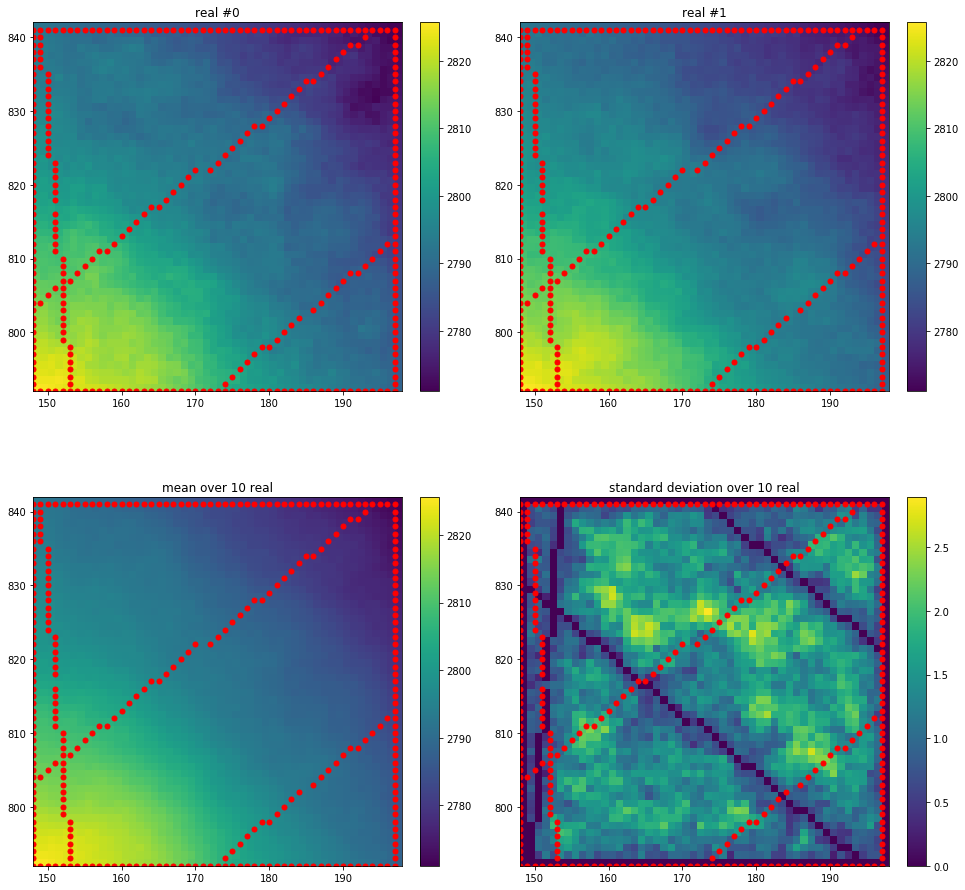

In [271]:
plt.subplots(2, 2,figsize=(16,16)) # plot with 4 sub-plots

# 2 first sub-plots: 2 first realizations
for i in (0, 1):
    plt.subplot(2,2,i+1)
    im_plot = plt.imshow(sim2Db[i],
                         extent=position,
                         interpolation='none')
    ccol.add_colorbar(im_plot)
    plt.plot(X[:,0],X[:,1], 'o', c='red', markersize=5) # add conditioning points
    plt.title('real #{}'.format(i))

# 3rd sub-plot: mean
plt.subplot(2,2,3)
im_plot = plt.imshow(sim2Db_mean,  
                     extent=position,
                     interpolation='none')
ccol.add_colorbar(im_plot)
plt.plot(X[:,0],X[:,1], 'o', c='red', markersize=5) # add conditioning points
plt.title('mean over {} real'.format(nreal))

# 4th sub-plot: standard deviation
plt.subplot(2,2,4)
im_plot = plt.imshow(sim2Db_std, 
                     extent=position,
                     interpolation='none')
ccol.add_colorbar(im_plot)
plt.plot(X[:,0],X[:,1], 'o', c='red', markersize=5) # add conditioning points
plt.title('standard deviation over {} real'.format(nreal))

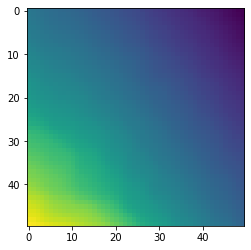

In [167]:
plt.imshow(trueMNT)

#### Krigeage

In [272]:
krig2Db, krig2Db_std = grf.krige2D(X, Y, cov_fun, dimension, spacing, origin, 
                                   extensionMin=extensionMin)

KRIGE2D: Computing circulant embedding...
KRIGE2D: Embedding dimension: 4096 x 4096
KRIGE2D: Computing FFT of circulant matrix...
KRIGE2D: Computing covariance matrix (rAA) for conditioning locations...
KRIGE2D: Computing index in the embedding grid for non-conditioning / conditioning locations...
KRIGE2D: computing kriging estimates...
KRIGE2D: computing kriging standard deviation ...


Text(0.5, 1.0, 'kriging standard deviation')

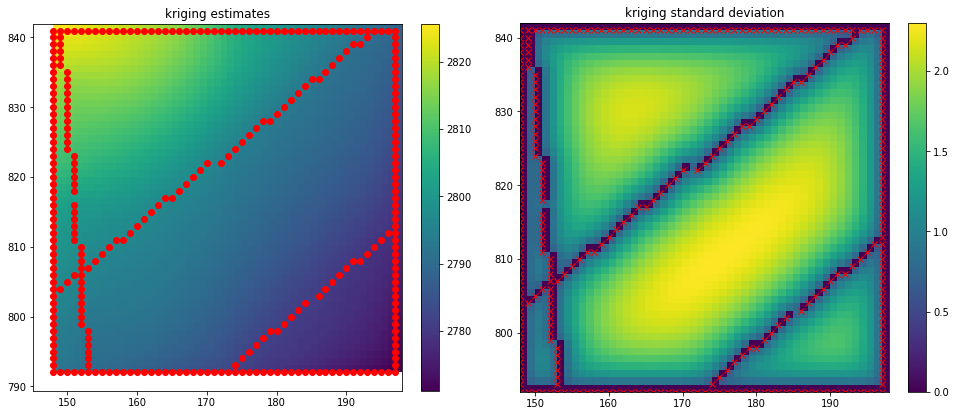

In [291]:
plt.subplots(1, 2,figsize=(16,16)) # plot with 2 sub-plots

# 1st sub-plot: kriging estimates
plt.subplot(1,2,1)
im_plot = plt.imshow(krig2Db, origin='lower',
                     extent=position,
                     interpolation='none')
ccol.add_colorbar(im_plot)
plt.scatter(X[:,0],X[:,1], c='red') # add conditioning points
plt.title('kriging estimates')

# 2nd sub-plot: kriging standard deviation
plt.subplot(1,2,2)
im_plot = plt.imshow(krig2Db_std,  origin='lower',
                     extent=position,
                     interpolation='none')
ccol.add_colorbar(im_plot)
plt.plot(X[:,0],X[:,1],marker='x',linewidth=0, c='red') # add conditioning points
plt.title('kriging standard deviation')

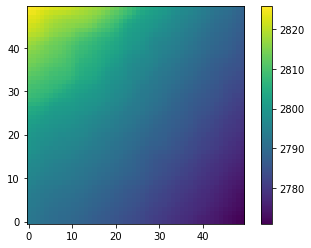

In [292]:
plt.imshow(trueMNT, origin='lower')
plt.colorbar()

#### Test regression linear

In [299]:
regLinear = lr().fit(X,Y)
regLinear.score(X,Y), regLinear.coef_

(0.9542311415554888, array([-0.14396598, -0.015295  ]))

In [310]:
#Linear regression model
grid = [np.arange(0,2500),np.arange(0,2500)]
grid = [[x,y] for x,y in zip(grid[0],grid[1])]
test = regLinear.predict(grid)


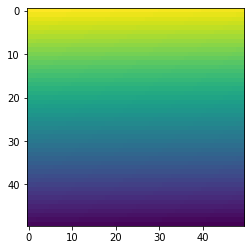

In [311]:
plt.imshow(test.reshape((50,50)))